# CHES-related analysis

This notebook is dedicated to the processing and analysis of trends of the CHES variables. 
Focus identities and related variables: 
- LRGEN: general left-right positioning,
- Families: The ideologies that the parties subscribe to
- GAL-TAN: Positioning of political parties according to the libertarian - traditional axis. 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df = pd.read_csv("../Sample/CHES-SI.tsv", sep="\t", encoding="utf-8")
cols = ["parlamint", "party_id", "party", "year", "lrgen", "galtan", "family", "seat"]
df = df[cols]
print(df.shape)
df.head()

(49, 8)


,parlamint,party_id,party,year,lrgen,galtan,family,seat
0,-,2909,AS,2006,4.6,2.6,7,0
1,-,2904,SLS-SMS,2010,6.8,7.8,4,5.6
2,DL,-,-,-,-,-,-,-
3,DLGV,-,-,-,-,-,-,-
4,DeSUS,2906,DeSUS,2002,3.4,5.8,9,4.4


In [3]:
#Parties in ParlaMint, but not in CHES: DL, DLGV, GAS, Konkretno, Lipa, NP, NeP
df = df[df["parlamint"]!="-"]
df = df[df["lrgen"] != "-"]

df.shape

(40, 8)

In [4]:
families={
    "1":"Radical Right", 
    "2":"Conservatives",
    "3":"Liberal", 
    "4":"Christian-Democratic",
    "5":"Socialist", 
    "6":"Radical Left", 
    "7":"Green", 
    "8":"Regionalist", 
    "9":"No family", 
    "10":"Confessional", 
    "11":"Agrarian/Center"
}

parties = {
    "ZL": "ZL/Levica",
    "Levica + ZL":"ZL/Levica",
    "Levica": "ZL/Levica",
    "AB":"ZaAB/ZaSLD/SAB",
    "ZaAB":"ZaAB/ZaSLD/SAB",
    "ZaSLD":"ZaAB/ZaSLD/SAB",
    "SAB" :"ZaAB/ZaSLD/SAB",
    "SAB + ZaSLD":"ZaAB/ZaSLD/SAB",
    "ZLSD":"ZLSD/SD",
    "SD":"ZLSD/SD",
    "SD + ZLSD":"ZLSD/SD",
    "SLS+SKD":"SLS+SKD/SLS",
    "SLS":"SLS+SKD/SLS", 
    "DLGV":"DLGV/DL", 
    "DL":"DLGV/DL",
    "SMC":"SMC/GAS/Konkretno",
    "Konkretno": "SMC/GAS/Konkretno"
}
df["family"] = df["family"].map(families).fillna(df["family"])
df["parties"] = df['parlamint'].replace(parties).fillna(df['parlamint'])

#df.to_csv("../Results/Datasets/CHES_Family.tsv", sep="\t", encoding="utf-8", index=False) #Saved for manual check

# Distributions

### Family
(CHES Codebook definition) "FAMILY= classification was initially based on Hix and Lord (1997), except that we place confessional and agrarian parties in separate categories. Family association for parties in Central/Eastern Europe was based initially on Derksen classification (now incorporated in Wikipedia), triangulated by a) membership or aﬃliation with international and EU party associations, and b) self-identification. We update family codings based on ideological shifts or organizational changes."

In [5]:
#Check families
family_cols = ["parlamint", "parties", "party", "year", "family"]
family = df[family_cols]

family = family.sort_values(by=["parties", "year"])
family["family_change"] = family.groupby("parties")["family"].transform(lambda x: x != x.iloc[0])
changes = family[family["family_change"] != False]

print("Parties with family changes:")
print(changes)
#No changes in the Family during the years


Parties with family changes:
Empty DataFrame
Columns: [parlamint, parties, party, year, family, family_change]
Index: []


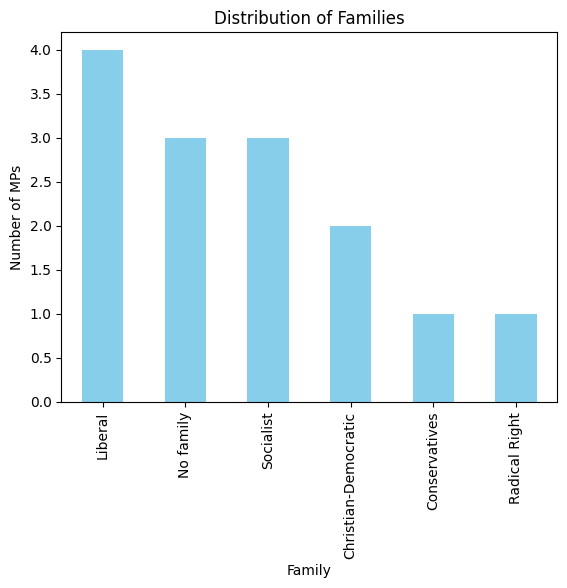

In [6]:
family = family.drop_duplicates(subset="parties").reset_index(drop=True)
family_counts = family["family"].value_counts()
family_counts.plot(kind='bar', color="skyblue")
plt.xlabel('Family')
plt.ylabel('Number of MPs')
plt.title('Distribution of Families')
plt.show()

In [7]:
col = ["parlamint", "parties", "family"]
family = family[col]
party_family = family.sort_values('parties')

latex_table = party_family.to_csv("../Results/Tables/Family.tsv", sep="\t", encoding="utf-8", index=False)

As no explicit change in the families exist for given years in the Family column, we checked the no. of parties in each of the Families. However, the barplot and Families labels (or the table) are not applicable for overall ParlaMint corpus, as a) we have missing years, parties and data and most importantly b) the families are calculated for individual year, so even if there is no explicit change for the parties in the CHES data, this cannot be said for the remaining parties in ParlaMint which are not in the CHES dataset. Therefore this plot only serves as orientation.

That being said, for the years that we do have, the parties in CHES belong to the following families (estimation): 
- DeSUS - No family
- LDS - Liberal
- LMŠ - Liberal
- NSi - Christian-Democratic
- PS - Socialist
- SDS - Conservatives
- SLS+SDK - Christian-Democratic
- SMC - Liberal
- SMS - No family
- SNS - Radical Right
- Levica (and ZL) - Socialist
- SD (and ZLSD) - Socialist
- ZaAB - No Family
- Zares - Liberal

## Left-right political positioning
LRGEN= position of the party in YEAR in terms of its overall ideological stance.
0 = Extreme left .. 5 = Center.. 10 = Extreme right

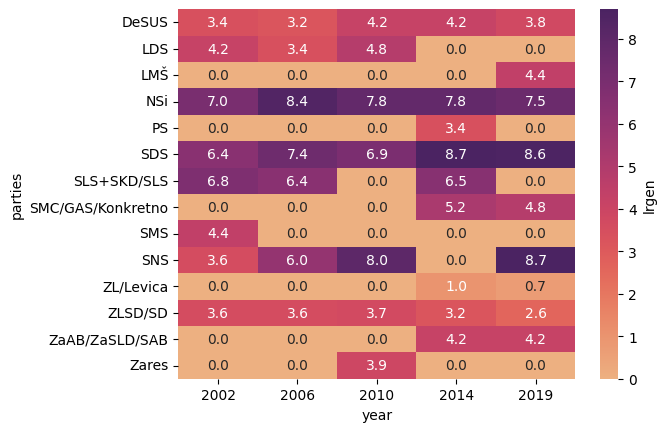

In [8]:
lrgen_pivot = df.pivot(index="parties", columns="year", values="lrgen").fillna(0)
lrgen_pivot = lrgen_pivot.astype(float)

sns.heatmap(
    lrgen_pivot, 
    annot=True, fmt=".1f", cmap="flare", cbar_kws={'label': 'lrgen'}
)
plt.show()

Parties x LRGEN heatmap: 
Comparing the parties/groups to their LRGEN score per Years (also available in a form of a lineplot for individual party), we can see the following trends: 
- The highest LRGEN score belongs to SNS in 2019. Additionally, SNS seems to be the only party with a very clear transition in their orientation (starting as a more centre-left party with LRGEN of 3.6, and moving to (far) right position with LRGEN score of 8.7)
- On the other extreme we have ZL/Levica, which shows scores of 1.0 and below (note: scores are only for the years 2014 and 2019, as the party was not part of the Parliament before this period). 
- For Zares, PS and LMŠ, SMS we really have only one plot point (as the parties were only present in one particular term)

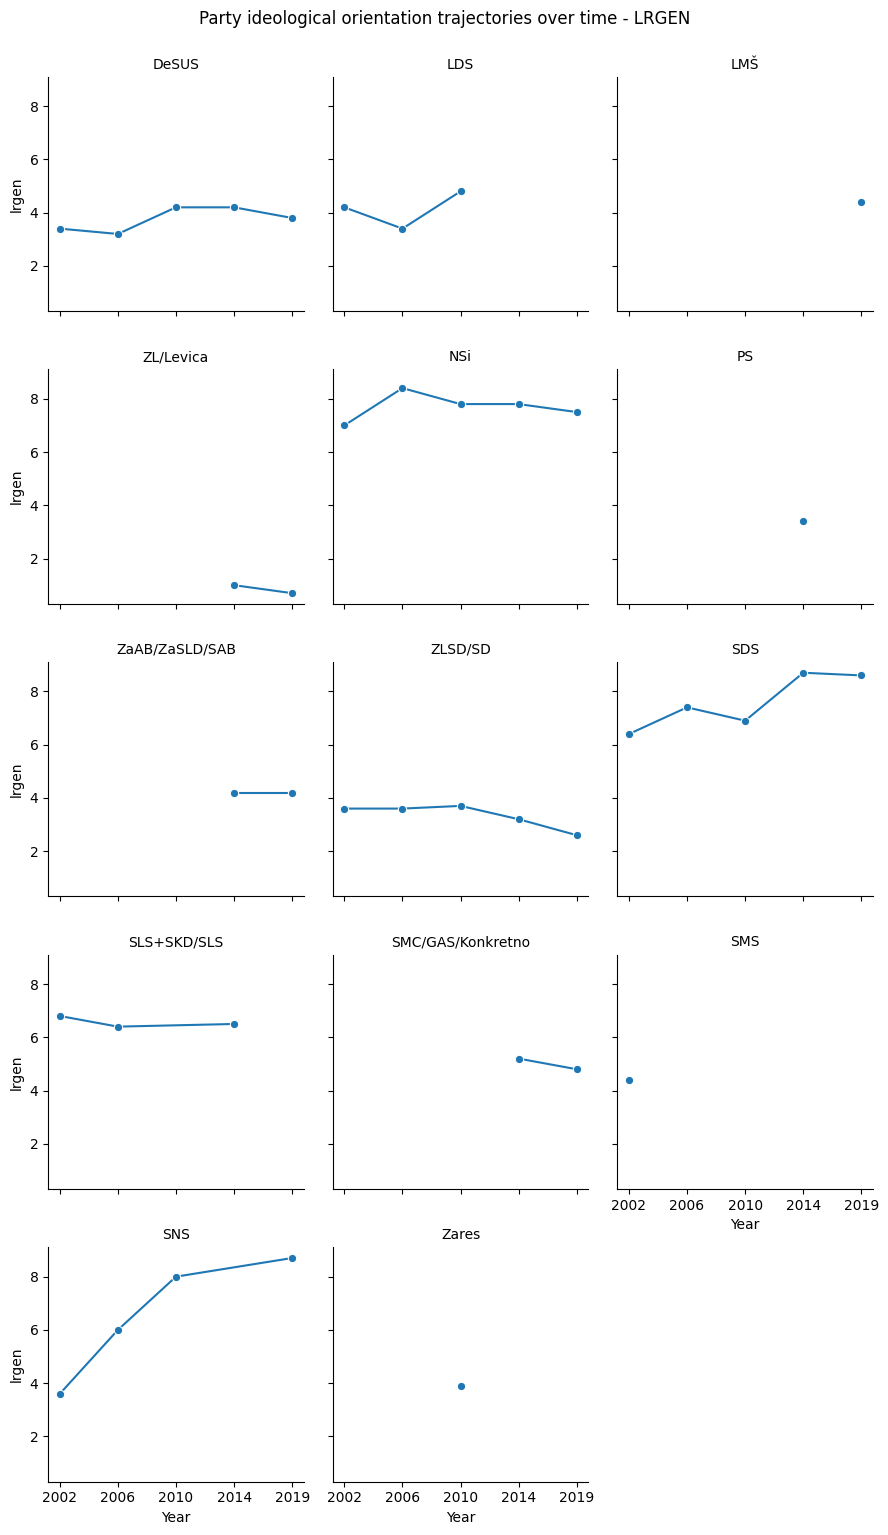

In [9]:
import numpy as np
df["lrgen"] = pd.to_numeric(df["lrgen"])
g = sns.FacetGrid(df, col="parties", col_wrap=3, height=3, sharey=True)
g.map_dataframe(sns.lineplot, x="year", y="lrgen", marker="o")

g.set_axis_labels("Year", "lrgen")
g.set_titles("{col_name}")
g.figure.suptitle("Party ideological orientation trajectories over time - LRGEN", y=1.02)

plt.show()

Mostly the same changes in orientation as described above. However, this plot allows us to visualy investigate the changes (and magnitude of change) for individual party, where with the exception of SNS (and Zares with one plot point), most parties do not go through dramatic changes in their orientation/their changes in LRGEN value are not that steep. For example: the LRGEN score for ZLSD/SD drops gradually from around 3.7 to 2.6 in 2014 and 2019, while for SDS, lrgen takes a slight dip in 2010 (from 7.4 in 2010 to 6.9), and then picks up, reaching 8.6 in 2019, the second highest LRGEN score overall.

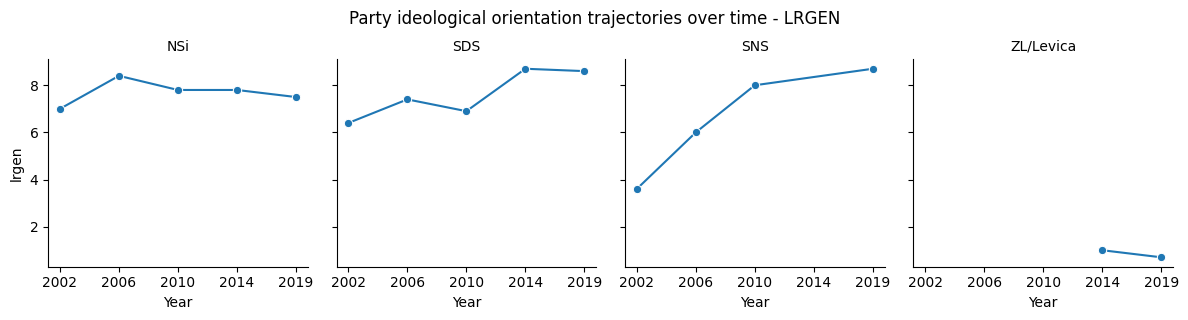

In [10]:
#Selection of most interesting patterns for Chapter III: 
select = ["SNS", "ZL/Levica", "SDS", "NSi"]
lrgen_select = df[df["parties"].isin(select)].sort_values(by=["parties","year"]).reset_index(drop=True)
lrgen_select

g = sns.FacetGrid(lrgen_select, col="parties", col_wrap=4, height=3, sharey=True)
g.map_dataframe(sns.lineplot, x="year", y="lrgen", marker="o")

g.set_axis_labels("Year", "lrgen")
g.set_titles("{col_name}")
g.figure.suptitle("Party ideological orientation trajectories over time - LRGEN", y=1.05)

plt.show()

Selection of four parties with the more interesting trends - LRGEN (Chapter)

## Social and cultural positioning GAL-TAN 
Position of the party in 2019 in terms of their views on social and cultural values.
“Libertarian” or “postmaterialist” parties favor expanded personal freedoms, for example, abortion
rights, divorce, and same-sex marriage. “Traditional” or “authoritarian” parties reject these ideas
in favor of order, tradition, and stability, believing that the government should be a firm moral
authority on social and cultural issues.
0 = Libertarian/Postmaterialist .. 5 = center.. 10 = Traditional/Authoritarian

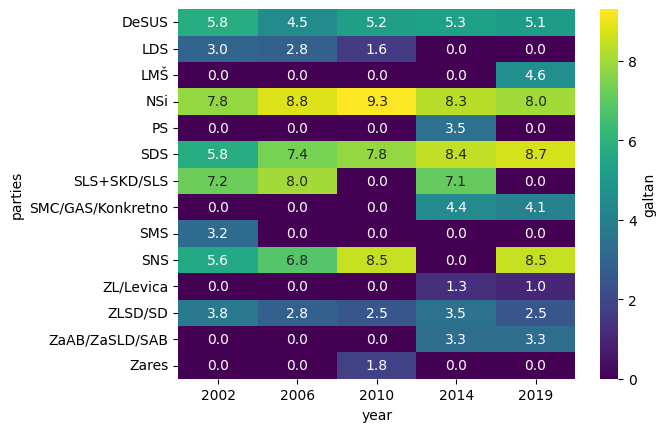

In [11]:
lrgen_pivot = df.pivot(index="parties", columns="year", values="galtan").fillna(0)
lrgen_pivot = lrgen_pivot.astype(float)

sns.heatmap(
    lrgen_pivot, 
    annot=True, fmt=".1f", cmap="viridis", cbar_kws={'label': 'galtan'},
)
plt.show()

Similarly to LRGEN, GALTAN denotes party positioning, but in terms of social and cultural values. The highest GALTAN score is reaches 9.3 (NSi, which then drops to 8.0 later in 2019), while the lowest score available is 1.0 (Levica in 2019). As before, we have parties with only one point (Zares, PS, SMS, LMŠ). 

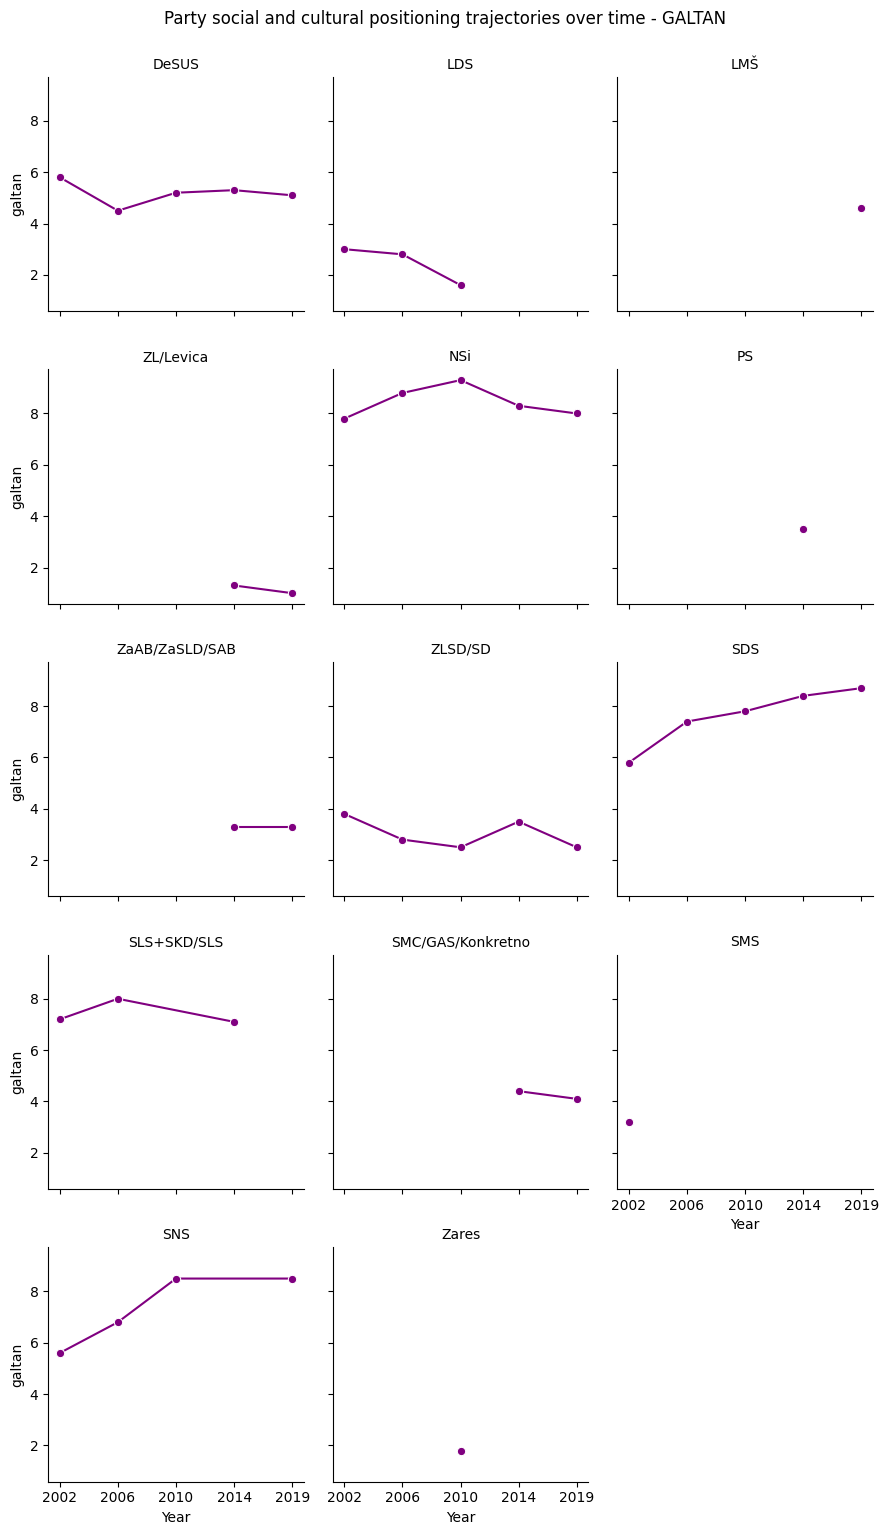

In [12]:
import numpy as np
df["galtan"] = pd.to_numeric(df["galtan"])
g = sns.FacetGrid(df, col="parties", col_wrap=3, height=3, sharey=True)
g.map_dataframe(sns.lineplot, x="year", y="galtan", marker="o", color="purple")

g.set_axis_labels("Year", "galtan")
g.set_titles("{col_name}")
g.figure.suptitle("Party social and cultural positioning trajectories over time - GALTAN", y=1.02)

plt.show()

The trends, identified in GALTAN lineplot are relatively similar in pattern to LRGEN patterns for individual parties, suggesting a connection between ideological and social/cultural values in party positioning.  

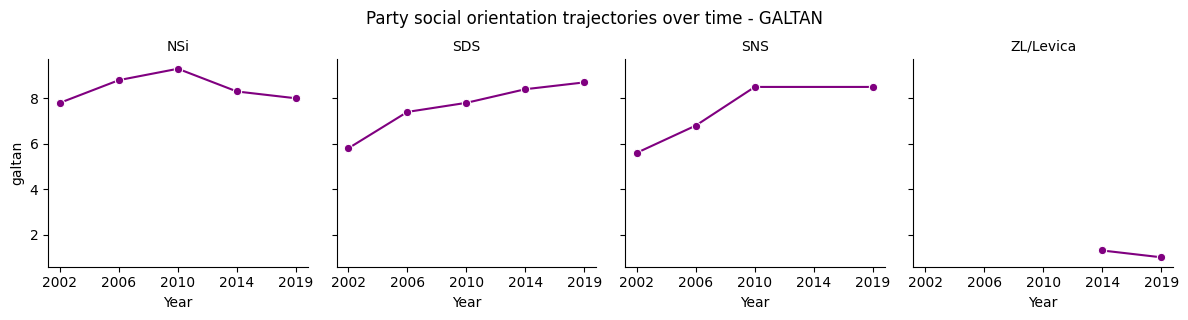

In [13]:
#Selection of most interesting patterns for Chapter III: 
select = ["SNS", "ZL/Levica", "SDS", "NSi"]
galtan_select = df[df["parties"].isin(select)].sort_values(by=["parties","year"]).reset_index(drop=True)
lrgen_select

g = sns.FacetGrid(galtan_select, col="parties", col_wrap=4, height=3, sharey=True)
g.map_dataframe(sns.lineplot, x="year", y="galtan", marker="o", color="purple")

g.set_axis_labels("Year", "galtan")
g.set_titles("{col_name}")
g.figure.suptitle("Party social orientation trajectories over time - GALTAN", y=1.05)

plt.show()

Selection of four parties with the more interesting trends - GALTAN (Chapter)

### LRGEN and GALTAN comparison

In [14]:
df["lrgen"] = pd.to_numeric(df["lrgen"], errors="coerce")
df["galtan"] = pd.to_numeric(df["galtan"], errors="coerce")
df["year"] = df["year"].astype(str)

lrgen_galtan = df.groupby(["parties", "year"]).agg(
    lrgen = ("lrgen", "mean"),
    galtan = ("galtan", "mean"),
).reset_index()

#cols = ["IMNS", "-", "NeP", "NP", "Lipa", "DLGV", "DL", "Konkretno"] #Speaker_party
cols = ["IMNS", "-", "NeP", "NP", "Lipa", "DLGV/DL", "Konkretno"] #Parties

lrgen_galtan = lrgen_galtan[~lrgen_galtan.isin(cols)]
lrgen_galtan.head(10)


,parties,year,lrgen,galtan
0,DeSUS,2002,3.4,5.8
1,DeSUS,2006,3.2,4.5
2,DeSUS,2010,4.2,5.2
3,DeSUS,2014,4.2,5.3
4,DeSUS,2019,3.8,5.1
5,LDS,2002,4.2,3.0
6,LDS,2006,3.4,2.8
7,LDS,2010,4.8,1.6
8,LMŠ,2019,4.4,4.6
9,NSi,2002,7.0,7.8


In [15]:
lrgen_galtan = lrgen_galtan.melt(
    id_vars=["parties", "year"],
    value_vars=["lrgen", "galtan"],
    var_name="Metric",
    value_name="Value"
)
lrgen_galtan

,parties,year,Metric,Value
0,DeSUS,2002,lrgen,3.4
1,DeSUS,2006,lrgen,3.2
2,DeSUS,2010,lrgen,4.2
3,DeSUS,2014,lrgen,4.2
4,DeSUS,2019,lrgen,3.8
...,...,...,...,...
75,ZLSD/SD,2014,galtan,3.5
76,ZLSD/SD,2019,galtan,2.5
77,ZaAB/ZaSLD/SAB,2014,galtan,3.3
78,ZaAB/ZaSLD/SAB,2019,galtan,3.3


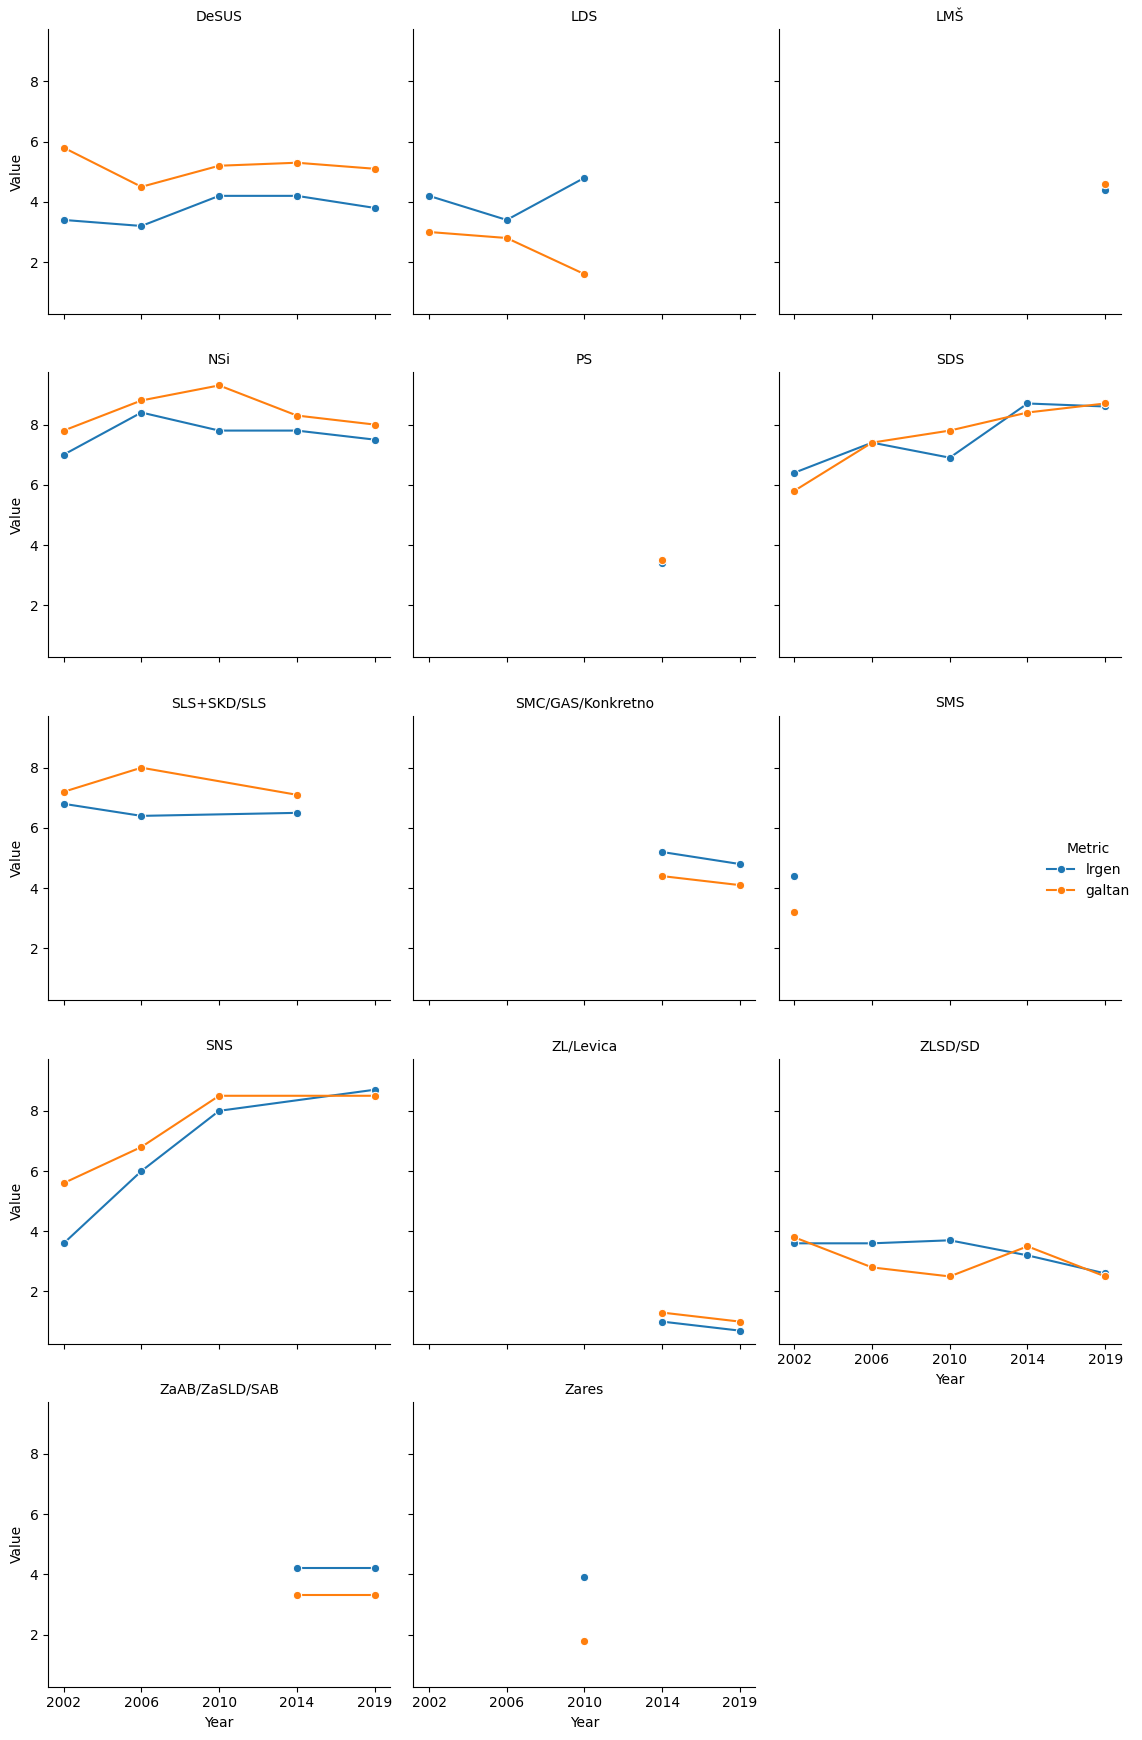

In [16]:

g = sns.FacetGrid(lrgen_galtan, col="parties", col_wrap=3, height=3.5, sharey=True, legend_out=True)
g.map_dataframe(sns.lineplot, x="year", y="Value", hue="Metric",marker="o")

g.add_legend(title="Metric")
g.set_axis_labels("Year", "Value")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

- As was indicated in the GALTAN-only plot, the GALTAN patterns are relatively similar to LRGEN, not so much in terms of scores, but the direction/changes that are very similar to the LRGEN pattern of change, though not always. 
- DeSUS patterns are almost identical (though the GALTAN scores are slightly higher, moving more towards traditional/authoritarian views, similar can be said for NSi, which is not too surprising as is ideological/LRGEN positioning is already more right-positioned). 
- In addition, parties like ZLSD/SD or LDS have lower GALTAN scores in comparison with their LRGEN scores, given their already more left-leaning LRGEN positioning, for which more libertarian-leaning GALTAN scores make sense. 
- One of the exceptions is Zares, for which we have only point plot, so we do not know much about their time-based trends, but we can see that there is a high(est) difference in their LRGEN (3.9)/GALTAN (1.8) scores, though they still remain on the more left/liberatrian axis.

In [17]:
lrgal_select = df[df["parties"].isin(select)].sort_values(by=["parties","year"]).reset_index(drop=True)
lrgal_select

lrgal_select = lrgal_select.groupby(["parties", "year"]).agg(
    lrgen = ("lrgen", "mean"),
    galtan = ("galtan", "mean"),
).reset_index()

lrgal_select = lrgal_select.melt(
    id_vars=["parties", "year"],
    value_vars=["lrgen", "galtan"],
    var_name="Metric",
    value_name="Value"
)
lrgal_select

,parties,year,Metric,Value
0,NSi,2002,lrgen,7.0
1,NSi,2006,lrgen,8.4
2,NSi,2010,lrgen,7.8
3,NSi,2014,lrgen,7.8
4,NSi,2019,lrgen,7.5
5,SDS,2002,lrgen,6.4
6,SDS,2006,lrgen,7.4
7,SDS,2010,lrgen,6.9
8,SDS,2014,lrgen,8.7
9,SDS,2019,lrgen,8.6


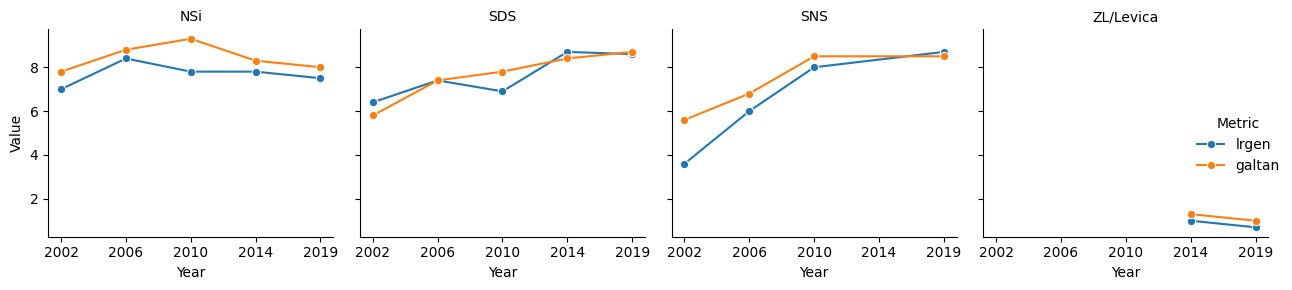

In [18]:
g = sns.FacetGrid(lrgal_select, col="parties", col_wrap=4, height=3, sharey=True, legend_out=True)
g.map_dataframe(sns.lineplot, x="year", y="Value", hue="Metric",marker="o")

g.add_legend(title="Metric")
g.set_axis_labels("Year", "Value")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

Selection of four parties with the more interesting trends -  LRGEN/GALTAN comparison(Chapter)

# Ideological and social positioning of parties in individual YEAR

In [ ]:
#Inspection of the 2019 data
df["year"] = df["year"].astype(float)
years = [2002, 2006, 2010, 2014, 2019]
df["seat"] = df["seat"].astype(float)

color_map = {
    "Radical Right":"blue", 
    "Conservatives":"aquamarine",
    "Liberal":"yellow", 
    "Christian-Democratic":"cornflowerblue",
    "Socialist":"lightsalmon", 
    "Radical Left":"coral", 
    "Green":"green", 
    "Regionalist":"lightcyan", 
    "No family":"violet", 
    "Confessional":"aqua", 
    "Agrarian/Center":"violet"
}

for year in years:
    df_year = df[df["year"]== year]
    df_year = df_year[df_year["seat"]!=0]
    fig = px.scatter(
        df_year, 
        x="lrgen", 
        y="galtan", 
        size="seat",
        color="family", 
        hover_name="parlamint",
        color_discrete_map=color_map,   
        title=f"LRGEN/GALTAN comparison for {year}",
    )
    fig.update_layout(
        height=500,
        width=900,
        xaxis_title="LRGEN score", 
        yaxis_title="GALTAN score",
        xaxis=dict(range=[0, 10]), 
        yaxis=dict(range=[0, 10]),
        legend_title_text="Family"
    )
    fig.add_shape(
        type="line",
        x0=0,
        x1=10,
        y0=df_year["galtan"].mean(),
        y1=df_year["galtan"].mean(),
        line=dict(dash="dash", color="gray")
    )
    fig.add_shape(
        type="line",
        x0=df_year["lrgen"].mean(),
        x1=df_year["lrgen"].mean(),
        y0=0,
        y1=10,
        line=dict(dash="dash", color="gray")
    )

    for i, row in df_year.iterrows():
        fig.add_annotation(
            x=row["lrgen"],
            y=row["galtan"],
            text=row["parlamint"],
            showarrow=False,
            font=dict(size=10),
            xanchor="left",
            yanchor="bottom"
        )

    
    
    fig.show()


In [25]:
df["Year"] = df["year"].astype("str")
lrgen_means= df.groupby("year")["lrgen"].mean()
lrgen_means

year
2002.0    4.925000
2006.0    5.485714
2010.0    5.614286
2014.0    4.911111
2019.0    5.033333
Name: lrgen, dtype: float64

In [26]:
galtan_means= df.groupby("year")["galtan"].mean()
galtan_means

year
2002.0    5.275000
2006.0    5.871429
2010.0    5.242857
2014.0    5.011111
2019.0    5.088889
Name: galtan, dtype: float64

Comparison of the LRGEN/GALTAN positioning of parties within individual year
General observations: the parties positioning for every Year are (mostly) clearly divided into left-lower quadrant (more left-winged and libertarian parties) and the right-upper quadrant (higher LRGEN/GALTAN scores, right-leaning and traditional social values). There are only minor exceptions to this division: 
- DeSUS: for years 2002, 2010, 2014, 2019 their LRGEN score is slightly more left-leaning, but their social/cultural positioning is more centric (lower GALTAN score). Only for the 2006 is their position alinged within the lower-left/upper-right quadrant division of parties (LRGEN:3.2, GALTAN:4.5)
- SMC: 2014, positioned as centre-left (LRGEN:5.2, GALTAN: 4.4)

2002: 
- SNS and DeSUS in the upper-left quadrant
- Average scores very close to the center (LRGEN - 4.9, GALTAN-5.27)
- Lower-left: SD + ZLSD, LDS, SMS; upper-right: SDS, NSi, SLS+SKD

2006:
- Lower-left: DeSUS, LDS, SD + ZLSD, upper-right: SNS, SLS, NSi, SDS -> one of the clearest divisions 
- Average scores slightly higer (lrgen:5.4, galtan:5.8), the quadrants are more unevenly distributed, with a clear split between left/libertarian and right/traditionalist parties.

2010:
- Desus in upper-left quadrant
- Lower-left: SD, Zares, LSD, Upper-right: SDS, SNS
- Average means (LRGEN - 5.61, GALTAN: 5.2) -> positioned slightly above and to the right of the mean lines. 

2014: 
- Average means (LRGEN - 4.92, GALTAN - 5.01) -> almost exactly centered quadrants, 
- Lower-left: Levica+SD, ZaAB, SD; upper-right: SDS, NSi; 
- Upper-left: DeSUS, lower-right: SMC (slightly more right-leaning, though centric in social values, LRGEN:5.2, GALTAN:4.4), largest share of seats

2019: 
- Several centre-left parties: DeSUS (lrgen: 3.8, galtan:5.1), LMŠ, SMC, SAB+ZaLSD (around 4.0 LRGEN and GALTAN score). 
- Levica moves even further in the lower left quadrant (low GALTAN/LRGEN score, extremly left-libertarian positioning)
- SNS is back in the Parliament, surpasing SDS and is now positioned in the most upper-right quadrant (of course with SDS having the majority share of the seats).
